In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [2]:
FEATURE_PATH="/kaggle/input/datasets/varshavp13/multimodal-features"

video_features=np.load(FEATURE_PATH+"/video_features.npy")

audio_features=np.load(FEATURE_PATH+"/audio_features.npy")

labels=np.load(FEATURE_PATH+"/labels.npy")

print(video_features.shape)
print(audio_features.shape)
print(labels.shape)

(1000, 768)
(1000, 768)
(1000,)


In [3]:
X_video_train,X_video_test,\
X_audio_train,X_audio_test,\
y_train,y_test=train_test_split(

video_features,
audio_features,
labels,

test_size=0.20,

random_state=42,

stratify=labels

)

X_video_train,X_video_val,\
X_audio_train,X_audio_val,\
y_train,y_val=train_test_split(

X_video_train,
X_audio_train,
y_train,

test_size=0.20,

random_state=42,

stratify=y_train

)

print(X_video_train.shape)
print(X_video_val.shape)
print(X_video_test.shape)

(640, 768)
(160, 768)
(200, 768)


In [4]:
class MultimodalDataset(Dataset):

    def __init__(self,video,audio,label):

        self.video=torch.FloatTensor(video)

        self.audio=torch.FloatTensor(audio)

        self.label=torch.LongTensor(label)

    def __len__(self):

        return len(self.label)

    def __getitem__(self,idx):

        return (

            self.video[idx],

            self.audio[idx],

            self.label[idx]

        )

In [5]:
train_dataset=MultimodalDataset(

X_video_train,

X_audio_train,

y_train

)

val_dataset=MultimodalDataset(

X_video_val,

X_audio_val,

y_val

)

test_dataset=MultimodalDataset(

X_video_test,

X_audio_test,

y_test

)

train_loader=DataLoader(

train_dataset,

batch_size=32,

shuffle=True

)

val_loader=DataLoader(

val_dataset,

batch_size=32,

shuffle=False

)

test_loader=DataLoader(

test_dataset,

batch_size=32,

shuffle=False

)

print(len(train_loader))

print(len(val_loader))

print(len(test_loader))

20
5
7


In [6]:
DEVICE="cuda" if torch.cuda.is_available() else "cpu"

print(DEVICE)

cuda


In [8]:
import torch
import torch.nn as nn

class HybridFusionNet(nn.Module):

    def __init__(self):

        super(HybridFusionNet, self).__init__()

        # -------------------------
        # Video Encoder
        # -------------------------
        self.video_encoder = nn.Sequential(

            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU()

        )

        # -------------------------
        # Audio Encoder
        # -------------------------
        self.audio_encoder = nn.Sequential(

            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU()

        )

        # -------------------------
        # Attention Fusion
        # -------------------------
        self.attention = nn.Sequential(

            nn.Linear(512,256),

            nn.ReLU(),

            nn.Linear(256,2),

            nn.Softmax(dim=1)

        )

        # -------------------------
        # Final Classifier
        # -------------------------
        self.classifier = nn.Sequential(

            nn.Linear(256,128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128,64),

            nn.ReLU(),

            nn.Linear(64,2)

        )

    def forward(self,video,audio):

        video_feature=self.video_encoder(video)

        audio_feature=self.audio_encoder(audio)

        combined=torch.cat(
            (video_feature,audio_feature),
            dim=1
        )

        weights=self.attention(combined)

        video_weight=weights[:,0].unsqueeze(1)

        audio_weight=weights[:,1].unsqueeze(1)

        fused_feature=(
            video_weight*video_feature
            +
            audio_weight*audio_feature
        )

        output=self.classifier(fused_feature)

        return output

In [9]:
model=HybridFusionNet().to(DEVICE)

criterion=nn.CrossEntropyLoss()

optimizer=torch.optim.Adam(

    model.parameters(),

    lr=1e-4

)

print(model)

HybridFusionNet(
  (video_encoder): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
  )
  (audio_encoder): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
  )
  (attention): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=2, bias=True)
    (3): Softmax(dim=1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (

In [10]:
def train_one_epoch(model,loader):

    model.train()

    running_loss=0

    correct=0

    total=0

    for video,audio,label in loader:

        video=video.to(DEVICE)

        audio=audio.to(DEVICE)

        label=label.to(DEVICE)

        optimizer.zero_grad()

        outputs=model(video,audio)

        loss=criterion(outputs,label)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()

        pred=outputs.argmax(1)

        correct+=(pred==label).sum().item()

        total+=label.size(0)

    return running_loss/len(loader),100*correct/total

In [11]:
def evaluate(model,loader):

    model.eval()

    total_loss=0

    correct=0

    total=0

    preds=[]

    actual=[]

    probabilities=[]

    with torch.no_grad():

        for video,audio,label in loader:

            video=video.to(DEVICE)

            audio=audio.to(DEVICE)

            label=label.to(DEVICE)

            outputs=model(video,audio)

            loss=criterion(outputs,label)

            total_loss+=loss.item()

            pred=outputs.argmax(1)

            preds.extend(pred.cpu().numpy())

            actual.extend(label.cpu().numpy())

            probabilities.extend(
                torch.softmax(outputs,dim=1)[:,1].cpu().numpy()
            )

            correct+=(pred==label).sum().item()

            total+=label.size(0)

    return (

        total_loss/len(loader),

        100*correct/total,

        preds,

        actual,

        probabilities

    )

In [12]:
train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []

best_acc = 0

EPOCHS = 20

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc, _, _, _ = evaluate(
        model,
        val_loader
    )

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Train Acc {train_acc:.2f}"
        f" | Val Acc {val_acc:.2f}"
    )

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_hybrid_fusion.pth"
        )

Epoch 1/20 | Train Acc 55.47 | Val Acc 50.00
Epoch 2/20 | Train Acc 74.22 | Val Acc 70.62
Epoch 3/20 | Train Acc 77.50 | Val Acc 75.62
Epoch 4/20 | Train Acc 80.47 | Val Acc 74.38
Epoch 5/20 | Train Acc 85.31 | Val Acc 80.62
Epoch 6/20 | Train Acc 88.28 | Val Acc 84.38
Epoch 7/20 | Train Acc 93.12 | Val Acc 86.88
Epoch 8/20 | Train Acc 93.75 | Val Acc 86.88
Epoch 9/20 | Train Acc 94.53 | Val Acc 88.75
Epoch 10/20 | Train Acc 96.56 | Val Acc 88.75
Epoch 11/20 | Train Acc 98.59 | Val Acc 88.75
Epoch 12/20 | Train Acc 97.19 | Val Acc 88.75
Epoch 13/20 | Train Acc 97.97 | Val Acc 91.88
Epoch 14/20 | Train Acc 98.28 | Val Acc 89.38
Epoch 15/20 | Train Acc 98.12 | Val Acc 90.00
Epoch 16/20 | Train Acc 98.91 | Val Acc 88.12
Epoch 17/20 | Train Acc 98.44 | Val Acc 89.38
Epoch 18/20 | Train Acc 98.44 | Val Acc 88.12
Epoch 19/20 | Train Acc 98.91 | Val Acc 90.62
Epoch 20/20 | Train Acc 97.81 | Val Acc 90.00


In [13]:
model.load_state_dict(
    torch.load("best_hybrid_fusion.pth")
)

test_loss, test_acc, preds, actual, probabilities = evaluate(
    model,
    test_loader
)

print(f"\nTest Accuracy : {test_acc:.2f}%")


Test Accuracy : 88.50%


In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print(classification_report(actual, preds))

print("Confusion Matrix")
print(confusion_matrix(actual, preds))

print("Accuracy :", test_acc)

print("Precision :", precision_score(actual, preds))

print("Recall :", recall_score(actual, preds))

print("F1 Score :", f1_score(actual, preds))

print("ROC AUC :", roc_auc_score(actual, probabilities))

              precision    recall  f1-score   support

           0       0.91      0.85      0.88       100
           1       0.86      0.92      0.89       100

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.89      0.89      0.88       200

Confusion Matrix
[[85 15]
 [ 8 92]]
Accuracy : 88.5
Precision : 0.8598130841121495
Recall : 0.92
F1 Score : 0.8888888888888888
ROC AUC : 0.944


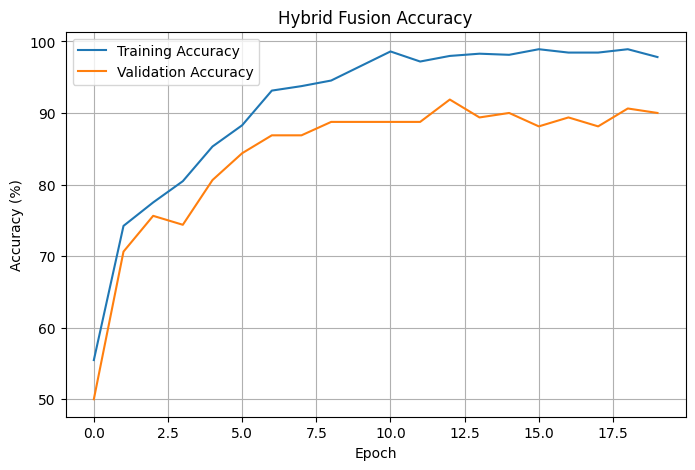

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_acc_history,
         label="Training Accuracy")

plt.plot(val_acc_history,
         label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Hybrid Fusion Accuracy")

plt.legend()

plt.grid()

plt.show()

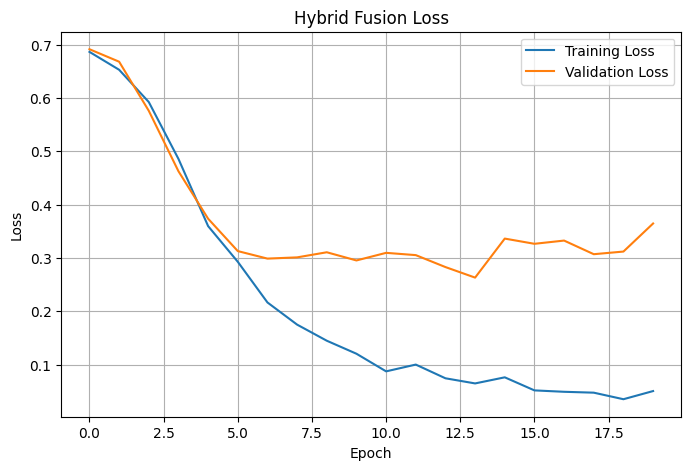

In [16]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_history,
         label="Training Loss")

plt.plot(val_loss_history,
         label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Hybrid Fusion Loss")

plt.legend()

plt.grid()

plt.show()

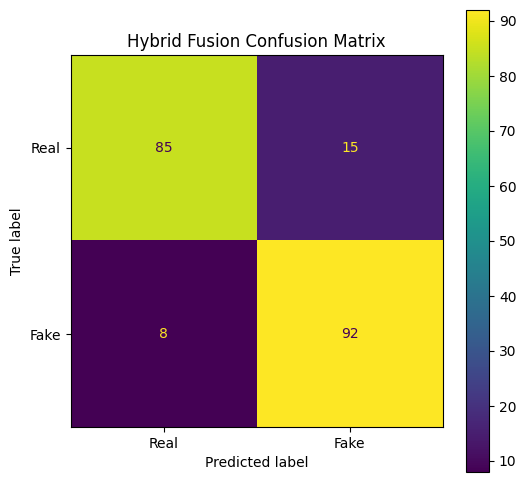

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(actual, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real","Fake"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(ax=ax)

plt.title("Hybrid Fusion Confusion Matrix")

plt.show()

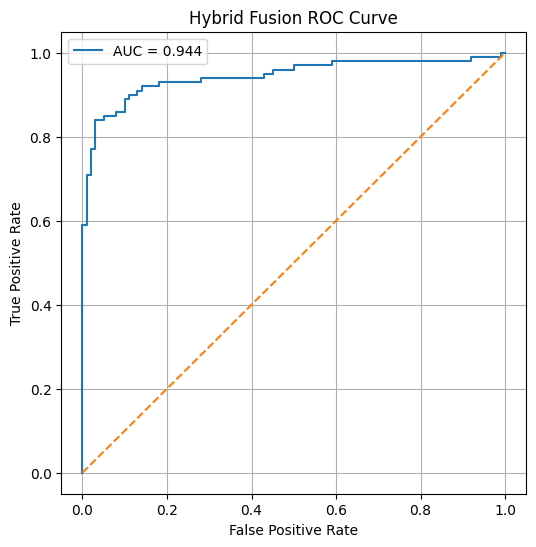

In [18]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(actual, probabilities)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr,
         tpr,
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Hybrid Fusion ROC Curve")

plt.legend()

plt.grid()

plt.show()

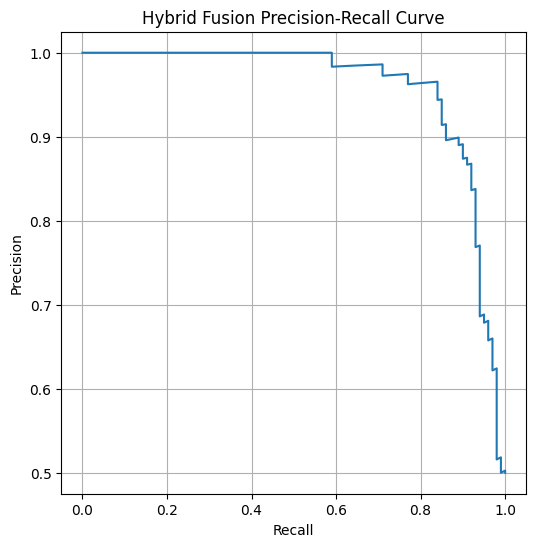

In [19]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    actual,
    probabilities
)

plt.figure(figsize=(6,6))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Hybrid Fusion Precision-Recall Curve")

plt.grid()

plt.show()

In [20]:
import pandas as pd

results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        test_acc,
        precision_score(actual,preds),
        recall_score(actual,preds),
        f1_score(actual,preds),
        roc_auc_score(actual,probabilities)
    ]

})

print(results)

      Metric      Value
0   Accuracy  88.500000
1  Precision   0.859813
2     Recall   0.920000
3   F1 Score   0.888889
4    ROC AUC   0.944000


In [21]:
torch.save(
    model.state_dict(),
    "Hybrid_Fusion_Final.pth"
)

print("Hybrid Fusion Model Saved Successfully!")

Hybrid Fusion Model Saved Successfully!
